In [ ]:
!pip install scikeras

## Case study

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

project_path = '/content/drive/MyDrive/Colab Notebooks/Real_Data_Application_MSVR'

if os.path.exists(project_path):
    os.chdir(project_path)
    print(f"Directory has changed to: {os.getcwd()}")
    
    print("Content detected", os.listdir())
else:
    print(f"The path {project_path} does not exist. Please verify the name of the Folders.")

### Import Required Libraries

Run the Required Libraries before executing any simulation or forecasting experiment.

In [ ]:
import os
from model.Base import Base
from model.MSVR import MSVR
from model.utility import (
    create_dataset,
    create_dataset_antes,
    rmse,
    CustomMSVR,
    create_dataset_rez,
    rezago_sig
)

from scikeras.wrappers import KerasRegressor

from scipy.linalg import orth
from scipy.stats import multivariate_normal

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import (
    RandomizedSearchCV,
    TimeSeriesSplit,
    train_test_split
)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.tsa.vector_ar.vecm import VECM, select_coint_rank

import csv
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

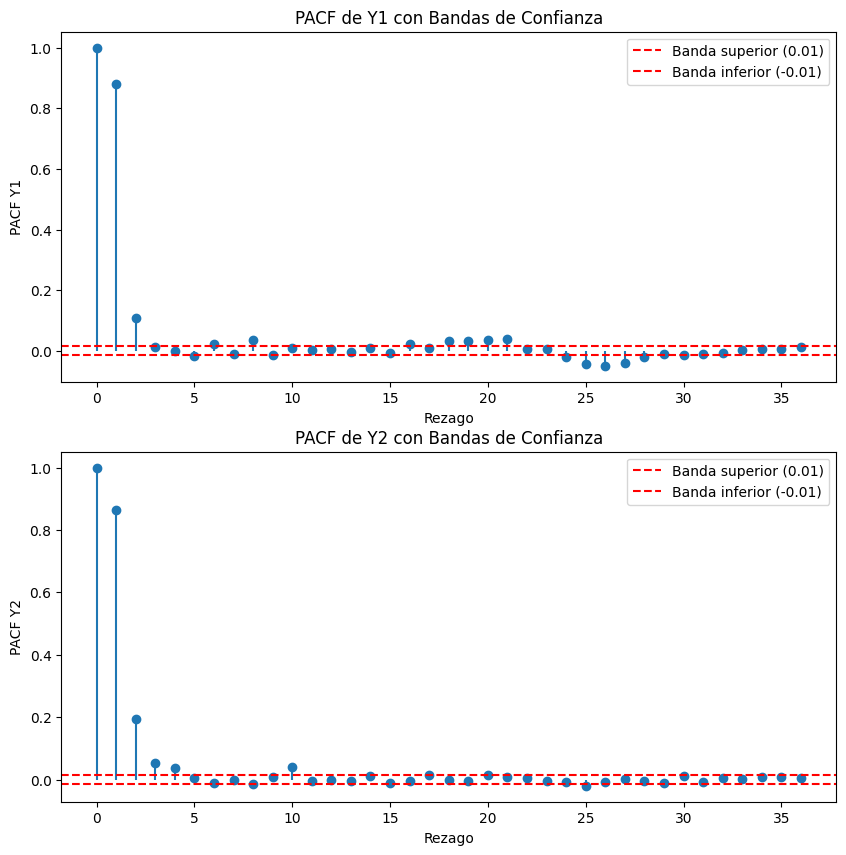

In [ ]:
file_path = "/xxx.xlsx"
data = pd.read_excel(file_path)
data=data

t = len(data)  # Length of the series
k = 2          # Dimension of the Y vector
p = 1          # Number of lags
h = 1
col = 2

# Save results

hiperparametros_svr = []
vectores_soporte=[]
train_RMSE_svr = []
test_RMSE_svr = []
train_RMSE_var = []
test_RMSE_var = []
tiempo_var=[]
tiempo_msvr=[]

# Generate the series and fit the models
series = data.iloc[:, 1:3]

#Split in train y test
train_size = int(len(series) * 0.7)
train, test = series.iloc[:train_size], series.iloc[train_size:]

#PACF
pacf_var1 = pacf(train['u_comp'], nlags=36)
pacf_var2 = pacf(train['v_comp'], nlags=36)
banda= 1.96 / np.sqrt(t)
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
# Plot
axes[0].stem(range(len(pacf_var1)), pacf_var1, basefmt=" ")
axes[0].axhline(y=banda, color='r', linestyle='--', label=f'upper band ({banda:.2f})')
axes[0].axhline(y=-banda, color='r', linestyle='--', label=f'lower band ({-banda:.2f})')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('PACF Y1')
axes[0].set_title('PACF of Y1 with confidence bands')
axes[0].legend()

# Plot
axes[1].stem(range(len(pacf_var2)), pacf_var2, basefmt=" ")
axes[1].axhline(y=banda, color='r', linestyle='--', label=f'upper band ({banda:.2f})')
axes[1].axhline(y=-banda, color='r', linestyle='--', label=f'lower band ({-banda:.2f})')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('PACF Y2')
axes[1].set_title('PACF of Y2 with confidence bands')
axes[1].legend()

In [ ]:
rez=24
#  VAR model
start_time = time.time()
model_var = VAR(train)
results_var = model_var.fit(maxlags=rez, ic='aic')
lag_order = results_var.k_ar

# Pred for train
train_pred = results_var.fittedvalues

# Pred for test 
test_pred = []
input_data = train.values[-rez:]
for i in range(len(test)):
    pred = results_var.forecast(y=input_data, steps=h)
    test_pred.append(pred[0])
    input_data = np.vstack([input_data[1:], test.values[i:i+1]])

test_pred = pd.DataFrame(test_pred, columns=['Predicción_Var1', 'Predicción_Var2'])

y_train_actual = train.iloc[lag_order:].to_numpy()
y_train_pred = train_pred.to_numpy()
train_rmse_var = np.sqrt(np.mean((y_train_actual - y_train_pred)**2))

test_rmse_var = np.sqrt(np.mean((test.to_numpy() - test_pred.to_numpy())**2))

# Export
train_combined = pd.concat([train.reset_index(drop=True), pd.DataFrame(index=range(len(train)), columns=['Predicción_Var1', 'Predicción_Var2'])], axis=1)
train_combined.iloc[lag_order:, 2:] = y_train_pred
test_combined = pd.concat([test.reset_index(drop=True), test_pred.reset_index(drop=True)], axis=1)

train_combined.to_excel('train_with_predictions_sergio_Var.xlsx', index=False)
test_combined.to_excel('test_with_predictions_sergio_var.xlsx', index=False)

print(f"VAR Train RMSE (Corregido): {train_rmse_var}")
print(f"VAR Test RMSE: {test_rmse_var}")
print("Archivos Excel actualizados.")

end_time = time.time()
execution_time = end_time - start_time
tiempo_var.append(execution_time)

VAR Train RMSE (Corregido): 4.152068302017432
VAR Test RMSE: 3.8969363150216134
Archivos Excel actualizados.


In [ ]:
import pandas as pd
import numpy as np

def compare_marginal_metrics(y_real, y_pred, excel_file, model_label, dataset_label):
    
    mask = ~np.isnan(y_pred).any(axis=1)
    y_r = y_real[mask]
    y_p = y_pred[mask]

    mem_u = np.sqrt(np.mean((y_r[:, 0] - y_p[:, 0])**2))
    mem_v = np.sqrt(np.mean((y_r[:, 1] - y_p[:, 1])**2))
    mem_global = np.sqrt(np.mean((y_r - y_p)**2))

   
    df_ex = pd.read_excel(excel_file)
    ex_u_r, ex_v_r = df_ex.iloc[:, 0].values, df_ex.iloc[:, 1].values
    ex_u_p, ex_v_p = df_ex.iloc[:, 2].values, df_ex.iloc[:, 3].values

    ex_mask = ~np.isnan(ex_u_p) & ~np.isnan(ex_v_p)
    ex_u = np.sqrt(np.mean((ex_u_r[ex_mask] - ex_u_p[ex_mask])**2))
    ex_v = np.sqrt(np.mean((ex_v_r[ex_mask] - ex_v_p[ex_mask])**2))
    ex_err_comb = np.concatenate([(ex_u_r[ex_mask] - ex_u_p[ex_mask]), (ex_v_r[ex_mask] - ex_v_p[ex_mask])])
    ex_global = np.sqrt(np.mean(ex_err_comb**2))

    print(f"\n=== COMPARACIÓN DETALLADA: {model_label} ({dataset_label}) ===")
    print(f"Métrica      | Python (Mem) | Excel (File) | Diff")
    print(f"-------------|--------------|--------------|----------")
    print(f"RMSE u_comp  | {mem_u:.6f}     | {ex_u:.6f}     | {abs(mem_u-ex_u):.2e}")
    print(f"RMSE v_comp  | {mem_v:.6f}     | {ex_v:.6f}     | {abs(mem_v-ex_v):.2e}")
    print(f"RMSE GLOBAL  | {mem_global:.6f}     | {ex_global:.6f}     | {abs(mem_global-ex_global):.2e}")


compare_marginal_metrics(train.iloc[lag_order:].values, y_train_pred, 'train_with_predictions_sergio_Var.xlsx', 'VAR', 'TRAIN')
compare_marginal_metrics(test.values, test_pred.values, 'test_with_predictions_sergio_var.xlsx', 'VAR', 'TEST')



=== COMPARACIÓN DETALLADA: VAR (TRAIN) ===
Métrica      | Python (Mem) | Excel (File) | Diff
-------------|--------------|--------------|----------
RMSE u_comp  | 3.837296     | 3.837296     | 0.00e+00
RMSE v_comp  | 4.444604     | 4.444604     | 0.00e+00
RMSE GLOBAL  | 4.152068     | 4.152068     | 0.00e+00

=== COMPARACIÓN DETALLADA: VAR (TEST) ===
Métrica      | Python (Mem) | Excel (File) | Diff
-------------|--------------|--------------|----------
RMSE u_comp  | 3.612781     | 3.612781     | 0.00e+00
RMSE v_comp  | 4.161735     | 4.161735     | 0.00e+00
RMSE GLOBAL  | 3.896936     | 3.896936     | 0.00e+00


In [ ]:
# Inicio MSVR versión original
start_time = time.time()
fechas = pd.DataFrame(list(range(len(series))))
total = pd.concat([fechas,series], axis=1).values
dim=len(total)

#Construcción de la base de datos
data=Base(total)
data= data.base

# Fix: Ensure 'col' is an integer before calling create_dataset_rez
col = 2 # Assuming 'col' should be 2 based on previous notebook context (e.g., k=2)

#Creamos la base de datos
dataset = create_dataset_rez(data,dim,h,col,rez)
X, Y = dataset[:, :(0 - h*2)], dataset[:, (0-h*2):]
#Train y test
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.3, shuffle=False)

#normalizados Standard Scaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

scaler_X.fit(X_train)
scaler_y.fit(y_train)

X_train_nor = scaler_X.transform(X_train)
X_test_nor = scaler_X.transform(X_test)
y_train_nor = scaler_y.transform(y_train)
y_test_nor = scaler_y.transform(y_test)
X_train_nor.shape




from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import warnings
from sklearn.exceptions import ConvergenceWarning

# Opcional: Ocultar avisos en caso de que alguna combinación muy extrema roce el límite
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# 1. Definición de la malla separada por kernel
hyperparameters = [
    # --- SUB-MALLA 1: Kernel RBF (48 combinaciones) ---
    {
        'MSVR__kernel': ['rbf'],
        'MSVR__gamma': [0.001, 0.01, 0.1,0.2, 0.5],  # Rango amplio y puramente numérico
        'MSVR__C': [0.1, 1, 10, 20],            # C bajo y alto para explorar el margen
        'MSVR__epsilon': [0.05, 0.1,0.2, 0.5]       # Tolerancia del tubo de pérdida
    },
    # --- SUB-MALLA 2: Kernel Polinómico (96 combinaciones) ---
    {
        'MSVR__kernel': ['poly'],
        'MSVR__degree': [2, 3],
        'MSVR__gamma': [0.001, 0.01, 0.05],     # Gamma pequeño previene la explosión exponencial
        'MSVR__coef0': [0.5, 1.0],              # Estabiliza el producto interno
        'MSVR__C': [0.1, 1, 5, 10],             # C moderado para facilitar la convergencia
        'MSVR__epsilon': [0.1, 0.5]
    }
]

# 2. Configuración del Pipeline con límites de seguridad
pipe = Pipeline([
    ('MSVR', CustomMSVR(
        tol=0.01,        # Tolerancia relajada para acelerar la convergencia
        max_iter=10000    # Límite de seguridad
    ))
])

# 3. GridSearchtsCV
tscv= TimeSeriesSplit(n_splits=5)
bm = GridSearchCV(
    estimator=pipe,
    param_grid=hyperparameters,
    scoring='neg_mean_squared_error',
    cv=tscv,                # 5 pliegues secuenciales(144 combinaciones x 3 = 432 ajustes en total)
    verbose=2,
    error_score='raise',
    n_jobs=-1            # Paralelización en todos los núcleos disponibles
)

# 4. Ajuste
best_model = bm.fit(X_train_nor, y_train_nor)
print(best_model)

best_params = bm.best_params_

msvr = MSVR(kernel=bm.best_params_.get("MSVR__kernel"), gamma=bm.best_params_.get("MSVR__gamma"),
            epsilon=bm.best_params_.get("MSVR__epsilon"), C=bm.best_params_.get("MSVR__C"),
            degree=bm.best_params_.get("MSVR__degree"), coef0=bm.best_params_.get("MSVR__coef0"), tol=0.01)

msvr.fit(X_train_nor, y_train_nor)


trainPred_svr_nor = msvr.predict(X_train_nor)
testPred_svr_nor = msvr.predict(X_test_nor)

trainPred_svr  = scaler_y.inverse_transform(trainPred_svr_nor)
testPred_svr  = scaler_y.inverse_transform(testPred_svr_nor)
train_rmse_svr = rmse(y_train, trainPred_svr) ### Cálculo de rmse para el MSVR para train
test_rmse_svr = rmse(y_test, testPred_svr) ### Cálculo de rmse para el MSVR para test
train_pred_df = pd.DataFrame(trainPred_svr, columns=['Predicción_Var1', 'Predicción_Var2'])
test_pred_df = pd.DataFrame(testPred_svr, columns=['Predicción_Var1', 'Predicción_Var2'])

# Create DataFrames for real values, ensuring they align with y_train/y_test
# This ensures the 'real' values in the Excel match what's used in memory for RMSE
train_real_df = pd.DataFrame(y_train, columns=['u_comp', 'v_comp']) # Use actual y_train values
test_real_df = pd.DataFrame(y_test, columns=['u_comp', 'v_comp']) # Use actual y_test values

# Concatenate the real and predicted DataFrames
train_combined = pd.concat([train_real_df, train_pred_df], axis=1)
test_combined = pd.concat([test_real_df, test_pred_df], axis=1)

# Guardar en archivos CSV
#train_combined.to_csv('train_with_prediction_svr_1_sergio.csv', index=False)
#test_combined.to_csv('test_with_predictions_svr_1_sergio.csv', index=False)

train_combined.to_excel('train_with_prediction_svr_1_sergio.xlsx', index=False)
test_combined.to_excel('test_with_predictions_svr_1_sergio.xlsx', index=False)

hiperparametros_svr.append(best_params)
vectores_soporte.append(msvr.NSV)
print("SVR Best params:", msvr.NSV/t)
train_RMSE_svr.append(train_rmse_svr)
test_RMSE_svr.append(test_rmse_svr)

end_time = time.time()
execution_time = end_time - start_time
tiempo_msvr.append(execution_time)


print("SVR Best params:", best_params)
print("VAR Train RMSE:", train_rmse_var, "Test RMSE:", test_rmse_var)
print("SVR Train RMSE:", train_rmse_svr, "Test RMSE:", test_rmse_svr)


# --- Ejecución de Comparativa para SVR ---
# These lines are moved here to ensure y_train, y_test, trainPred_svr, and testPred_svr are defined.
compare_marginal_metrics(y_train, trainPred_svr, 'train_with_prediction_svr_1_sergio.xlsx', 'SVR', 'TRAIN')
compare_marginal_metrics(y_test, testPred_svr, 'test_with_predictions_svr_1_sergio.xlsx', 'SVR', 'TEST')

#  Persistence Model

In [ ]:
import time
import pandas as pd
import numpy as np


start_time = time.time()

persistence_train_pred = train.iloc[:-1].values 
persistence_train_real = train.iloc[1:].values 

persistence_train_pred = train.iloc[lag_order - 1:-1].values
persistence_train_real = train.iloc[lag_order:].values


persistence_test_pred_list = []


last_train_val = train.iloc[-1:].values
persistence_test_pred_list.append(last_train_val[0])


for i in range(len(test) - 1):
    persistence_test_pred_list.append(test.iloc[i].values)

persistence_test_pred = np.array(persistence_test_pred_list)
persistence_test_real = test.values

# Calculate RMSE
persistence_train_rmse = rmse(persistence_train_real, persistence_train_pred)
persistence_test_rmse = rmse(persistence_test_real, persistence_test_pred)

# Export to Excel
persistence_train_real_df = pd.DataFrame(persistence_train_real, columns=['u_comp', 'v_comp'])
persistence_test_real_df = pd.DataFrame(persistence_test_real, columns=['u_comp', 'v_comp'])

# DataFrames for pred
persistence_train_pred_df = pd.DataFrame(persistence_train_pred, columns=['Predicción_Var1', 'Predicción_Var2'])
persistence_test_pred_df = pd.DataFrame(persistence_test_pred, columns=['Predicción_Var1', 'Predicción_Var2'])

persistence_train_combined = pd.concat([persistence_train_real_df, persistence_train_pred_df], axis=1)
persistence_test_combined = pd.concat([persistence_test_real_df, persistence_test_pred_df], axis=1)

persistence_train_combined.to_excel('train_with_predictions_sergio_Persistence.xlsx', index=False)
persistence_test_combined.to_excel('test_with_predictions_sergio_Persistence.xlsx', index=False)

end_time = time.time()
execution_time = end_time - start_time
tiempo_msvr.append(execution_time) 

print(f"RMSE Modelo de Persistencia (TRAIN): {persistence_train_rmse:.6f}")
print(f"RMSE Modelo de Persistencia (TEST): {persistence_test_rmse:.6f}")



RMSE Modelo de Persistencia (TRAIN): 4.402154
RMSE Modelo de Persistencia (TEST): 4.144456

=== COMPARACIÓN DETALLADA: PERSISTENCE (TRAIN) ===
Métrica      | Python (Mem) | Excel (File) | Diff
-------------|--------------|--------------|----------
RMSE u_comp  | 4.038231     | 4.038231     | 0.00e+00
RMSE v_comp  | 4.738206     | 4.738206     | 0.00e+00
RMSE GLOBAL  | 4.402154     | 4.402154     | 0.00e+00

=== COMPARACIÓN DETALLADA: PERSISTENCE (TEST) ===
Métrica      | Python (Mem) | Excel (File) | Diff
-------------|--------------|--------------|----------
RMSE u_comp  | 3.813905     | 3.813905     | 0.00e+00
RMSE v_comp  | 4.450523     | 4.450523     | 0.00e+00
RMSE GLOBAL  | 4.144456     | 4.144456     | 0.00e+00


In [ ]:
import pandas as pd
import numpy as np

# Función interna para obtener métricas marginales
def get_marginal_rmse(real, pred):
    rmse_u = np.sqrt(np.mean((real[:, 0] - pred[:, 0])**2))
    rmse_v = np.sqrt(np.mean((real[:, 1] - pred[:, 1])**2))
    return rmse_u, rmse_v

# Cálculo de métricas marginales para todos los modelos
var_u_train, var_v_train = get_marginal_rmse(train.iloc[lag_order:].values, y_train_pred)
var_u_test, var_v_test = get_marginal_rmse(test.values, test_pred.values)

n_train = len(y_train_pred)
msvr_u_train, msvr_v_train = get_marginal_rmse(y_train[-n_train:], trainPred_svr[-n_train:])
msvr_u_test, msvr_v_test = get_marginal_rmse(y_test, testPred_svr)

pers_u_train, pers_v_train = get_marginal_rmse(persistence_train_real, persistence_train_pred)
pers_u_test, pers_v_test = get_marginal_rmse(persistence_test_real, persistence_test_pred)

# 1. Mostrar tabla comparativa extendida
resultados_full = pd.DataFrame({
    'Modelo': ['VAR', 'MSVR', 'Persistencia'],
    'Train RMSE Global': [train_rmse_var, train_rmse_svr, persistence_train_rmse],
    'Train RMSE u_comp': [var_u_train, msvr_u_train, pers_u_train],
    'Train RMSE v_comp': [var_v_train, msvr_v_train, pers_v_train],
    'Test RMSE Global': [test_rmse_var, test_rmse_svr, persistence_test_rmse],
    'Test RMSE u_comp': [var_u_test, msvr_u_test, pers_u_test],
    'Test RMSE v_comp': [var_v_test, msvr_v_test, pers_v_test]
})

print("=== COMPARACIÓN GLOBAL Y UNIVARIADA DE RMSE ===")
display(resultados_full)

# 2. Consolidar archivos (se mantiene la lógica de alineación previa)
consolidado_train = pd.DataFrame(y_train[-n_train:], columns=['Real_u_comp', 'Real_v_comp'])
consolidado_train['VAR_u_pred'] = y_train_pred[:, 0]
consolidado_train['VAR_v_pred'] = y_train_pred[:, 1]
consolidado_train['MSVR_u_pred'] = trainPred_svr[-n_train:, 0]
consolidado_train['MSVR_v_pred'] = trainPred_svr[-n_train:, 1]
consolidado_train['Persistencia_u_pred'] = persistence_train_pred[:, 0]
consolidado_train['Persistencia_v_pred'] = persistence_train_pred[:, 1]

n_test = len(testPred_svr)
consolidado_test = pd.DataFrame(y_test, columns=['Real_u_comp', 'Real_v_comp'])
consolidado_test['VAR_u_pred'] = test_pred.values[-n_test:, 0]
consolidado_test['VAR_v_pred'] = test_pred.values[-n_test:, 1]
consolidado_test['MSVR_u_pred'] = testPred_svr[:, 0]
consolidado_test['MSVR_v_pred'] = testPred_svr[:, 1]
consolidado_test['Persistencia_u_pred'] = persistence_test_pred[-n_test:, 0]
consolidado_test['Persistencia_v_pred'] = persistence_test_pred[-n_test:, 1]

# Exportar a Excel
consolidado_train.to_excel('consolidado_train.xlsx', index=False)
consolidado_test.to_excel('consolidado_test.xlsx', index=False)

print("\nArchivos 'consolidado_train.xlsx' y 'consolidado_test.xlsx' generados con éxito.")

# Diagnostics VAR model

Residuales extraídos exitosamente. Primeras 5 filas:


,u_comp,v_comp
2,0.123351,1.887990
3,-0.045619,2.168189
4,-1.160633,1.753933
5,1.866631,1.825552
6,2.305269,-1.432701


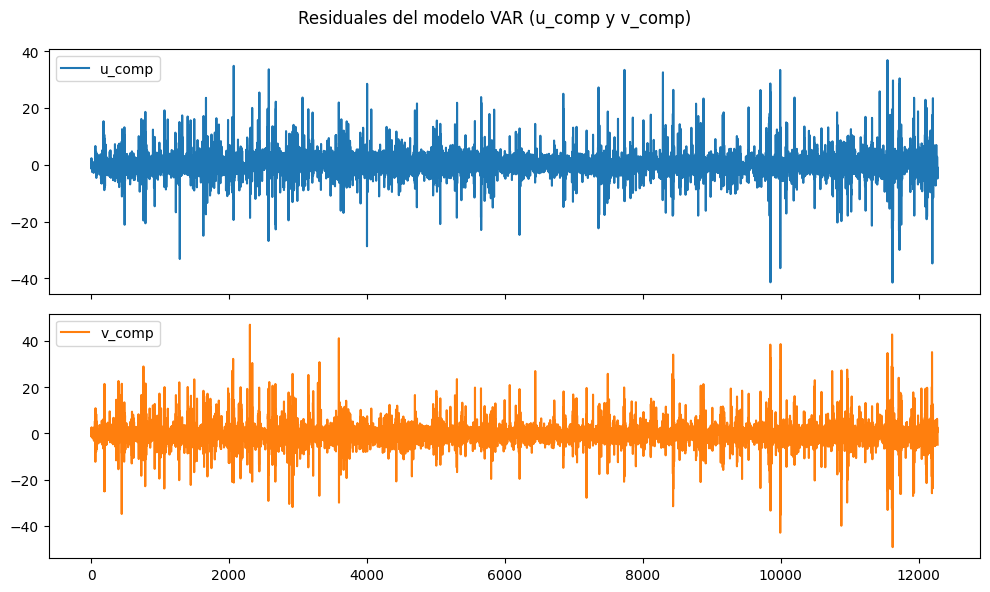

In [ ]:
#  Get residuals from the fitted VAR model

residuales_var = results_var.resid

print("Residuales extraídos exitosamente. Primeras 5 filas:")
display(residuales_var.head())
# Quick residual diagnostics for white noise
residuales_var.plot(subplots=True, figsize=(10, 6), title='Residuales del modelo VAR (u_comp y v_comp)')
plt.tight_layout()
plt.show()

# VAR Model Diagnostic Tests
 Evaluate whether the residuals behave as white noise and assess their normality.

In [ ]:
whiteness_test = results_var.test_whiteness(nlags=30)
print(whiteness_test.summary())

Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 30 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         493.8          137.7   0.000 112
-----------------------------------------


In [ ]:
# Multivariate Normality Test
normality_test = results_var.test_normality()
print(normality_test.summary())

normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
     2.469e+05          9.488   0.000  4
----------------------------------------


In [ ]:
from statsmodels.stats.diagnostic import het_arch

# Residuals
residuals = results_var.resid

#  ARCH Test for each residuals
for col in residuals.columns:
    arch_test = het_arch(residuals[col], nlags=5)
    p_value = arch_test[1]
    print(f"Variable '{col}' - Test ARCH p-valor: {p_value:.4f}")

Variable 'u_comp' - Test ARCH p-valor: 0.0000
Variable 'v_comp' - Test ARCH p-valor: 0.0000


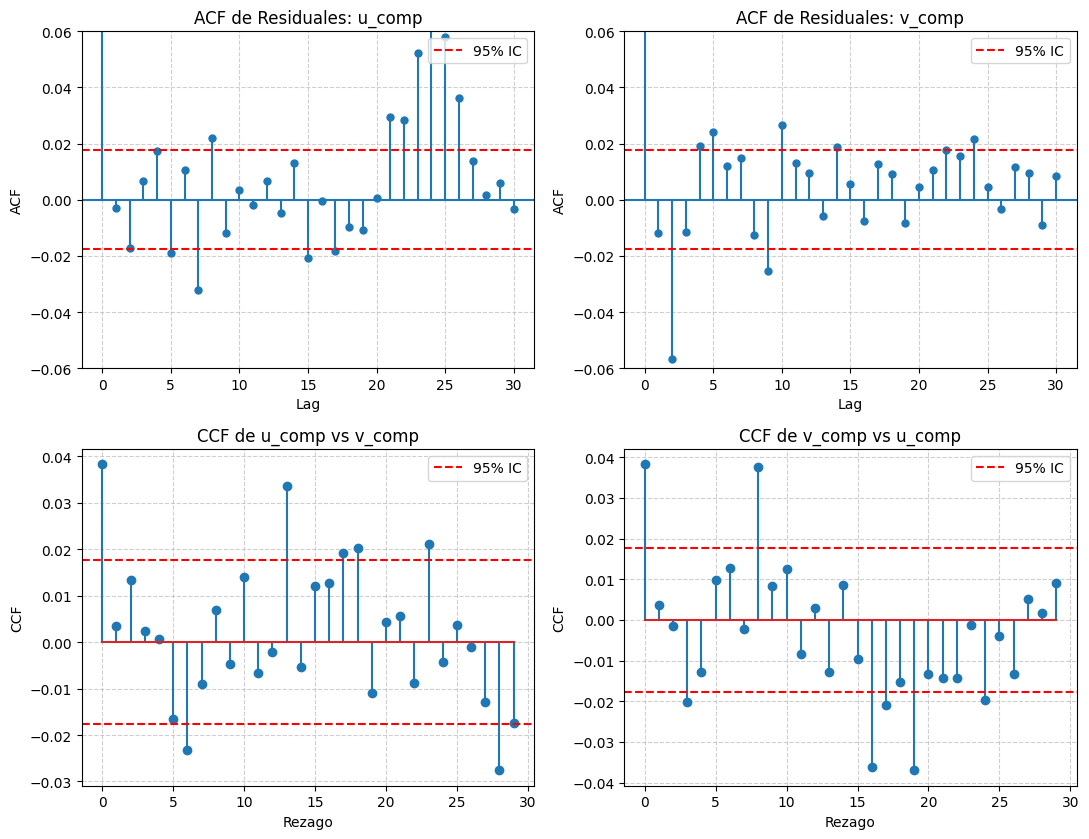

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import ccf
import matplotlib.pyplot as plt
import numpy as np

# VAR model residuals
residuals = results_var.resid

# Calculate the number of observations for the confidence bands


n_obs = len(residuals.dropna()) # Use the length of the non-null residuals, assuming it is the same for both series
conf_interval_bound = 1.96 / np.sqrt(n_obs)

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))

# --- Gráfica 1: ACF de 'u_comp' ---
plot_acf(residuals['u_comp'], lags=30, ax=axes[0, 0], title='ACF de Residuales: u_comp', alpha=None) # Establecer alpha=None para eliminar el sombreado por defecto

axes[0, 0].axhline(y=conf_interval_bound, color='r', linestyle='--', label='95% IC')
axes[0, 0].axhline(y=-conf_interval_bound, color='r', linestyle='--')
axes[0, 0].set_xlabel('Lag')
axes[0, 0].set_ylabel('ACF')
axes[0, 0].set_ylim([-0.06, 0.06]) 
axes[0, 0].grid(True, linestyle='--', alpha=0.6)
axes[0, 0].legend(loc='upper right')

# --- Gráfica 2: ACF de 'v_comp' ---
plot_acf(residuals['v_comp'], lags=30, ax=axes[0, 1], title='ACF de Residuales: v_comp', alpha=None) # Establecer alpha=None para eliminar el sombreado por defecto

axes[0, 1].axhline(y=conf_interval_bound, color='r', linestyle='--', label='95% IC')
axes[0, 1].axhline(y=-conf_interval_bound, color='r', linestyle='--')
axes[0, 1].set_xlabel('Lag')
axes[0, 1].set_ylabel('ACF')
axes[0, 1].set_ylim([-0.06, 0.06]) 
axes[0, 1].grid(True, linestyle='--', alpha=0.6)
axes[0, 1].legend(loc='upper right')

# --- Gráfica 3: CCF de u_comp (con v_comp como referencia) ---
ccf_uv = ccf(residuals['u_comp'], residuals['v_comp'], adjusted=False, nlags=30)
axes[1, 0].stem(range(len(ccf_uv)), ccf_uv)
axes[1, 0].axhline(y=conf_interval_bound, color='r', linestyle='--', label='95% IC')
axes[1, 0].axhline(y=-conf_interval_bound, color='r', linestyle='--')
axes[1, 0].set_title('CCF de u_comp vs v_comp')
axes[1, 0].set_xlabel('Rezago')
axes[1, 0].set_ylabel('CCF')
axes[1, 0].grid(True, linestyle='--', alpha=0.6)
axes[1, 0].legend(loc='upper right')

# --- Gráfica 4: CCF de v_comp (con u_comp como referencia) ---
ccf_vu = ccf(residuals['v_comp'], residuals['u_comp'], adjusted=False, nlags=30)
axes[1, 1].stem(range(len(ccf_vu)), ccf_vu)
axes[1, 1].axhline(y=conf_interval_bound, color='r', linestyle='--', label='95% IC')
axes[1, 1].axhline(y=-conf_interval_bound, color='r', linestyle='--')
axes[1, 1].set_title('CCF de v_comp vs u_comp')
axes[1, 1].set_xlabel('Rezago')
axes[1, 1].set_ylabel('CCF')
axes[1, 1].grid(True, linestyle='--', alpha=0.6)
axes[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

fig.savefig('/content/autocorrresiduales.pdf', bbox_inches='tight')

In [ ]:
from statsmodels.stats.diagnostic import breaks_cusumolsresid

residuals = results_var.resid

print("Prueba CUSUM por variable:")
for col in residuals.columns:
    # CUSUM Test on the OLS Residual Series
    stat, p_value, _ = breaks_cusumolsresid(residuals[col])
    print(f"Variable '{col}': Estadística = {stat:.4f} | p-valor = {p_value:.4f}")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import periodogram

residuals = results_var.resid 

print("Análisis del Periodograma: Frecuencias Dominantes en los Residuales")
display(pd.DataFrame(resultados_picos))

# 5. Visualización del periodograma para cada variable
num_vars = len(residuals.columns)
fig, axes = plt.subplots(num_vars, 1, figsize=(10, 3 * num_vars), sharex=True)
if num_vars == 1:
    axes = [axes]

for i, col in enumerate(residuals.columns):
    
    freqs, spectrum = periodogram(residuals[col].dropna(), fs=1.0)

    axes[i].plot(freqs, spectrum)
    axes[i].set_title(f'Periodograma de los Residuales ({col})')
    axes[i].set_xlabel('Frecuencia (ciclos por observación)')
    axes[i].set_ylabel('Densidad Espectral')

plt.tight_layout()
plt.show()